In [2]:
import os
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)

PyTorch: 2.14.0
Torchvision: 0.29.0
OpenCV: 5.0.0


In [3]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Using device:", device)

if device.type == "mps":
    print("Apple Silicon GPU acceleration enabled!")
else:
    print("Using CPU")

Using device: mps
Apple Silicon GPU acceleration enabled!


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [5]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
VIDEO_DIR = DATA_DIR / "videos"
METADATA_DIR = DATA_DIR / "metadata"

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)

Project directory: /Users/varshh06/Desktop/DL END TO END/1. DL – SIGN LANGUAGE RECOGNITION SYSTEM
Data directory: /Users/varshh06/Desktop/DL END TO END/1. DL – SIGN LANGUAGE RECOGNITION SYSTEM/data


In [6]:
import urllib.request

metadata_url = (
    "https://raw.githubusercontent.com/dxli94/WLASL/"
    "master/start_kit/WLASL_v0.3.json"
)

metadata_path = METADATA_DIR / "WLASL_v0.3.json"

if not metadata_path.exists():
    urllib.request.urlretrieve(metadata_url, metadata_path)
    print("Metadata downloaded successfully.")
else:
    print("Metadata already exists.")

print("Metadata path:", metadata_path)

Metadata downloaded successfully.
Metadata path: /Users/varshh06/Desktop/DL END TO END/1. DL – SIGN LANGUAGE RECOGNITION SYSTEM/data/metadata/WLASL_v0.3.json


In [7]:
with open(metadata_path, "r") as f:
    wlasl_data = json.load(f)

print("Total classes in WLASL:", len(wlasl_data))

Total classes in WLASL: 2000


In [8]:
wlasl100 = wlasl_data[:100]

print("Number of classes selected:", len(wlasl100))

Number of classes selected: 100


In [9]:
class_to_idx = {
    item["gloss"]: idx
    for idx, item in enumerate(wlasl100)
}

idx_to_class = {
    idx: item["gloss"]
    for idx, item in enumerate(wlasl100)
}

print("First 10 classes:")

for idx in range(10):
    print(idx, "->", idx_to_class[idx])

First 10 classes:
0 -> book
1 -> drink
2 -> computer
3 -> before
4 -> chair
5 -> go
6 -> clothes
7 -> who
8 -> candy
9 -> cousin


In [10]:
records = []

for class_idx, item in enumerate(wlasl100):

    gloss = item["gloss"]

    for instance in item["instances"]:

        records.append({
            "gloss": gloss,
            "label": class_idx,
            "video_id": instance["video_id"],
            "split": instance["split"],
            "url": instance["url"]
        })

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2038, 5)


,gloss,label,video_id,split,url
0,book,0,69241,train,http://aslbricks.org/New/ASL-Videos/book.mp4
1,book,0,65225,train,https://aslsignbank.haskins.yale.edu/dictionar...
2,book,0,68011,train,https://www.youtube.com/watch?v=0UsjUE-TXns
3,book,0,68208,train,https://www.youtube.com/watch?v=1QOYOZ3g-aY
4,book,0,68012,train,https://www.youtube.com/watch?v=aGtIHKEdCds


In [11]:
print("Dataset split:")
print(df["split"].value_counts())

print("\nNumber of unique classes:")
print(df["gloss"].nunique())

print("\nTotal video instances:")
print(len(df))

Dataset split:
split
train    1442
val       338
test      258
Name: count, dtype: int64

Number of unique classes:
100

Total video instances:
2038


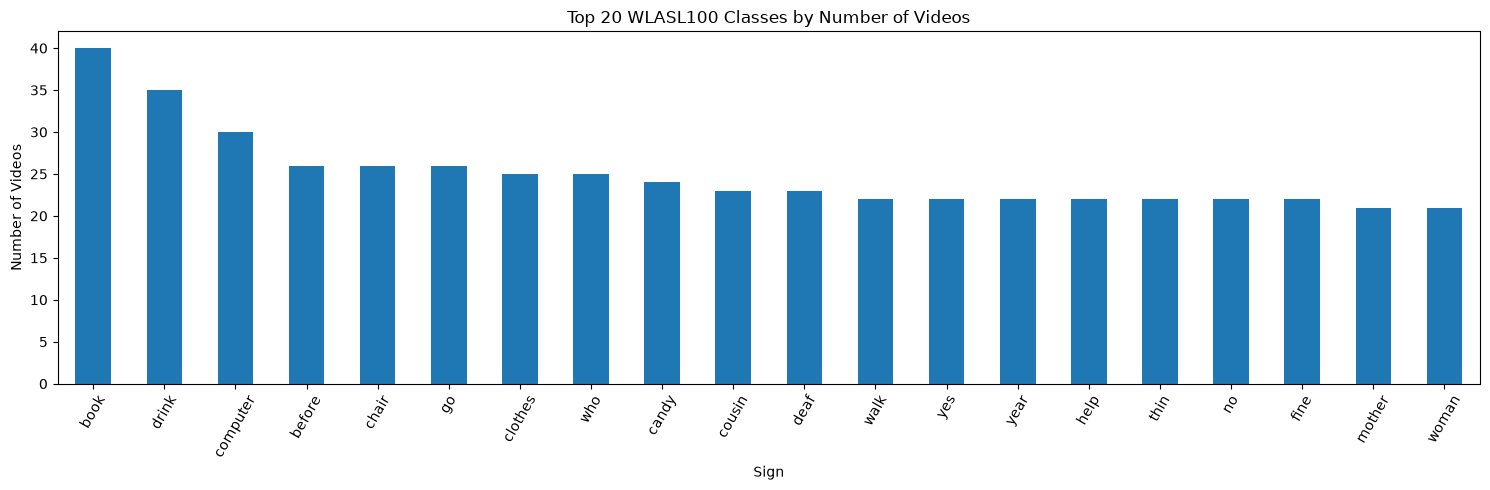

In [12]:
class_counts = df["gloss"].value_counts()

plt.figure(figsize=(15, 5))

class_counts.head(20).plot(kind="bar")

plt.title("Top 20 WLASL100 Classes by Number of Videos")
plt.xlabel("Sign")
plt.ylabel("Number of Videos")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()